Long Term memory

In [3]:
#imports
import os
import sys
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph,START,END,add_messages
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import HumanMessage,SystemMessage,BaseMessage,RemoveMessage,AIMessage
from langchain_core.prompts import SystemMessagePromptTemplate
from typing import List,Annotated,TypedDict
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

In [4]:
load_dotenv()
GROQ_LLM_API_KEY = os.getenv("GROQ_LLM_API_KEY")
GROQ_MODELS = os.getenv("GROQ_MODELS")

GEMINI_LLM_API_KEY= os.getenv("GEMINI_LLM_API_KEY")

llm = ChatGroq(model=GROQ_MODELS.split(",")[0],temperature=0.7,api_key=GROQ_LLM_API_KEY)
# llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash",temperature=0.7,api_key=GEMINI_LLM_API_KEY)


In [5]:
class GraphState(TypedDict):
    messages:Annotated[List[BaseMessage],add_messages]
    summary:str

In [6]:
def ask_question(state:GraphState):
    print(f"Starting with state\n{state}")
    print("How can I help you ?")
    prompt = input()
    human_message=HumanMessage(content=prompt)
    human_message.pretty_print()
    return {
        'messages':[human_message],
        'summary':state.get('summary','')
    }

In [7]:
fetchInfo_Msg = """
### Role
You are a context-aware assistant. You answer the user's latest question using the provided conversation summary as your memory.

### Context (History)
{summary}

### Instructions
1.  **Contextual Linking**: Use the summary to resolve pronouns (e.g., if summary says "Modi" and user asks "his age", "his" refers to Modi).
2.  **Brevity**: Provide a direct, factual answer based on the summary and your internal knowledge.
3.  **Gap Handling**: If the summary doesn't contain enough info to answer a specific follow-up, use your general knowledge but stay consistent with the summary's facts.
4.  **No Meta-Talk**: Do not mention "The summary states" or "According to the history." Just answer the question.
5.  If summary is not present , it means user doen't have any previous conversation 
6.  If no summary is present , you have to response to the query passed by the user in its message
### Output
[Direct Answer]
"""

fetchInfo_Template = SystemMessagePromptTemplate.from_template(template=fetchInfo_Msg)

def ask_llm(state:GraphState):
    messages = state.get("messages")
    summary = state.get('summary','')
    system_message = fetchInfo_Template.format(summary=summary)
    response = llm.invoke([system_message]+messages)
    newState=  {
        "messages":[system_message,AIMessage(content=response.content)],
        "summary":summary
    }
    return newState


In [8]:
templateMsg = """
You are a State Manager Summarizer Agent. 

Your goal is to distill the conversation history into a high-density, concise summary.
Follow these rules:
1. Identify the core intent of the user.
2. Preserve key facts, technical values, and specific user preferences.
3. List any unresolved questions or pending tasks.
4. Keep the summary as short as possible using clear and professional language without losing any context.

Previous Summary:
{summary} 
New Messages:
{messages}

Provide only the summary text.
"""
summarizeTemplate = SystemMessagePromptTemplate.from_template(template=templateMsg)

def summarize_response(state:GraphState):
    messages = state.get("messages")
    summary = state.get("summary")
    chat_history_str = "\n".join([f"{m.type}: {m.content}" for m in messages])
    system_message = summarizeTemplate.format(summary=summary,messages=chat_history_str)
    new_summary = llm.invoke(system_message.content)
    return {
        'messages':[system_message],
        'summary':new_summary.content
    }


In [9]:
def print_response_and_remove_messages(state:GraphState):
    messages = state.get("messages")
    last_ai_message= messages[-2] # last is system message
    last_ai_message.pretty_print()
    return {
        'messages':[RemoveMessage(id=i.id) for i in messages],
        'summary':state.get('summary','')
    }



In [10]:
workflow = StateGraph(GraphState)
workflow.add_node("ask_question",ask_question)
workflow.add_node("ask_llm",ask_llm)
workflow.add_node("summarize_response",summarize_response)
workflow.add_node("print_response_and_remove_messages",print_response_and_remove_messages)

workflow.add_edge(START,'ask_question')
workflow.add_edge("ask_question",'ask_llm')
workflow.add_edge("ask_llm",'summarize_response')
workflow.add_edge("summarize_response",'print_response_and_remove_messages')
workflow.add_edge("print_response_and_remove_messages",END)


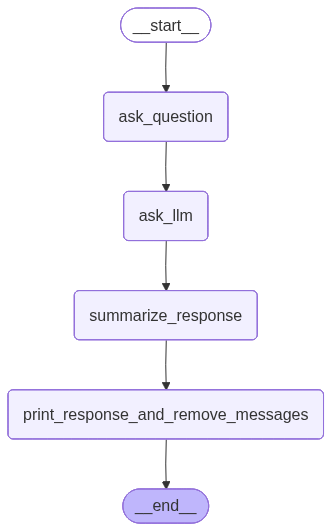

In [11]:
# Creating a app without memory
app = workflow.compile()
app

In [12]:
#Invoking it first Time
res=app.invoke(GraphState())

Starting with state
{'messages': []}
How can I help you ?
================================ Human Message =================================

What is the name of PM of india ?
================================== Ai Message ==================================

Droupadi Murmu is the President of India, and the Prime Minister of India is Narendra Modi.


In [13]:
res=app.invoke(GraphState())

Starting with state
{'messages': []}
How can I help you ?
================================ Human Message =================================

what is his age ?
================================== Ai Message ==================================

There is no information about a person's age as this is the beginning of our conversation and no context has been provided. Please provide more context or information about who "he" is.


Creating a app with short term memory

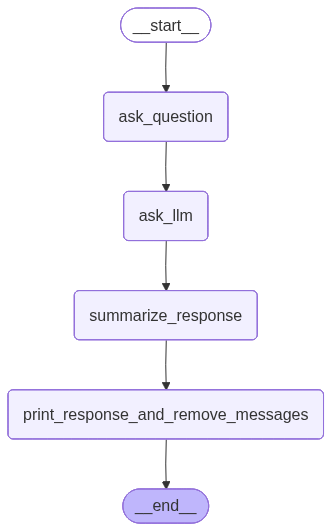

In [14]:
dbconn = sqlite3.connect('./memory.db',check_same_thread=False)
checkpointer = SqliteSaver(conn=dbconn)
# checkpointer = MemorySaver()
app_with_memory = workflow.compile(checkpointer=checkpointer)
app_with_memory 

In [15]:
config = {"configurable":{"thread_id":1}}

In [16]:
res=app_with_memory.invoke(GraphState(),config=config)

Starting with state
{'messages': []}
How can I help you ?
================================ Human Message =================================

who is the prime minister of india ?
================================== Ai Message ==================================

Droupadi Murmu is the President of India, and the Prime Minister of India is Narendra Modi.


In [17]:
res=app_with_memory.invoke(GraphState(),config=config)

Starting with state
{'messages': [], 'summary': 'The core intent of the user is to inquire about the Prime Minister of India. The key fact is that the Prime Minister of India is Narendra Modi, and Droupadi Murmu is the President of India. There are no unresolved questions or pending tasks.'}
How can I help you ?
================================ Human Message =================================

what is his age ?
================================== Ai Message ==================================

Narendra Modi was born on September 17, 1950. His age is 73.
